# Modelos de marea — Ría de Foz

In [ ]:
import sys, time
sys.path.insert(0, r"C:\Users\Jorge\sketch_fitton\Intertidal_analysis")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from intertidal.tidemodel import PyTMDTideModel, CopernicusTideModel

LAT, LON = 43.593075, -7.225533

# Muestreo cada 2 horas para capturar bien las oscilaciones
dates = pd.date_range("2024-01-01", "2024-06-30 23:00", freq="2h")  
print(f"{len(dates)} mediciones (cada 2h): {dates[0]} → {dates[-1]}")


2184 mediciones (cada 2h): 2024-01-01 00:00:00 → 2024-06-30 22:00:00


In [12]:
model_got = PyTMDTideModel(model_name="GOT4.10", directory="./tide_models", box_size=2.0, resolution=0.1)
t0 = time.time()
got = model_got.get_tide_heights_batch(LAT, LON, [d.to_pydatetime() for d in dates])
print(f"GOT4.10: {len(got)} mediciones en {time.time()-t0:.1f}s")

Modelo GOT4.10 ya descargado
GOT4.10: 2184 mediciones en 7.6s


In [13]:
model_cmems = CopernicusTideModel()
t0 = time.time()
cmems = model_cmems.get_tide_heights_batch(LAT, LON, [d.to_pydatetime() for d in dates])
print(f"CMEMS: {len(cmems)} mediciones en {time.time()-t0:.1f}s")

INFO - 2026-07-02T11:36:23Z - Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.
INFO:copernicusmarine:Using existing credentials from C:\Users\Jorge\.copernicusmarine\.copernicusmarine-credentials. Use --force-overwrite combined with credentials (specified by arguments, netrc file or environment variables) to always overwrite.
INFO - 2026-07-02T11:36:25Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-02T11:36:25Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


CMEMS: 2184 mediciones en 9.1s


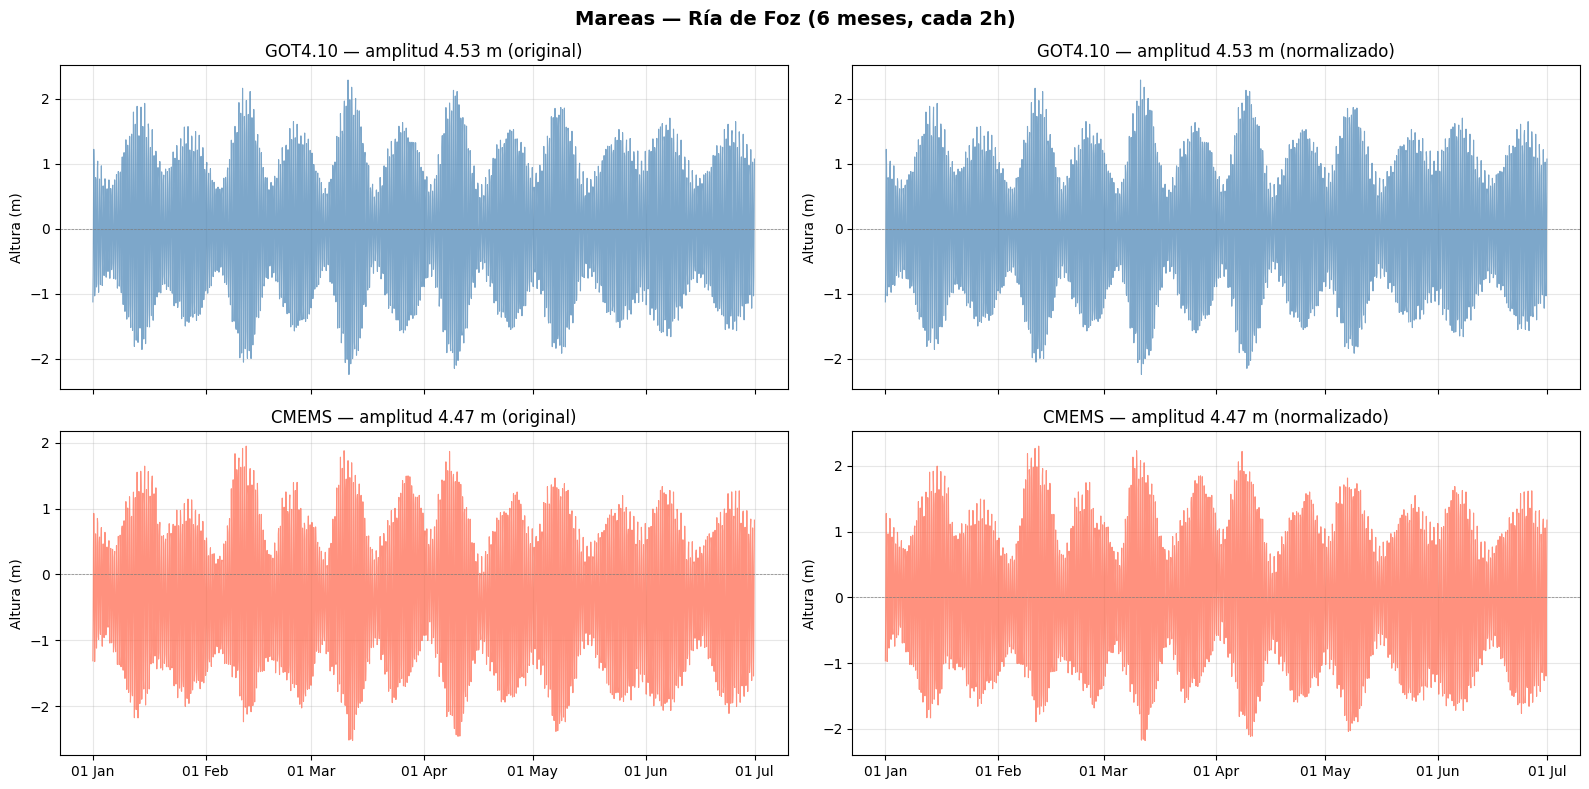

In [14]:
import numpy as np

df = pd.DataFrame({"date": dates, "GOT4.10": got, "CMEMS": cmems})

# Normalizar: restar la media de cada serie
df["GOT4.10_norm"] = df["GOT4.10"] - np.mean(df["GOT4.10"])
df["CMEMS_norm"] = df["CMEMS"] - np.mean(df["CMEMS"])

# ────────────────────────────────────────────────────────────────────
# FIGURA 1: Series temporales (originales y normalizadas)
# ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 8), sharex=True)

# Columna izquierda: series originales
for i, (col, color) in enumerate(zip(["GOT4.10", "CMEMS"], ["steelblue", "tomato"])):
    ax = axes[i, 0]
    ax.plot(df["date"], df[col], "-", color=color, linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    amp = df[col].max() - df[col].min()
    ax.set_title(f"{col} — amplitud {amp:.2f} m (original)")
    ax.set_ylabel("Altura (m)")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

# Columna derecha: series normalizadas
for i, (col, col_norm, color) in enumerate(zip(["GOT4.10", "CMEMS"], ["GOT4.10_norm", "CMEMS_norm"], ["steelblue", "tomato"])):
    ax = axes[i, 1]
    ax.plot(df["date"], df[col_norm], "-", color=color, linewidth=0.8, alpha=0.7)
    ax.axhline(0, color="gray", linewidth=0.5, linestyle="--")
    amp = df[col].max() - df[col].min()
    ax.set_title(f"{col} — amplitud {amp:.2f} m (normalizado)")
    ax.set_ylabel("Altura (m)")
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))

fig.suptitle("Mareas — Ría de Foz (6 meses, cada 2h)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

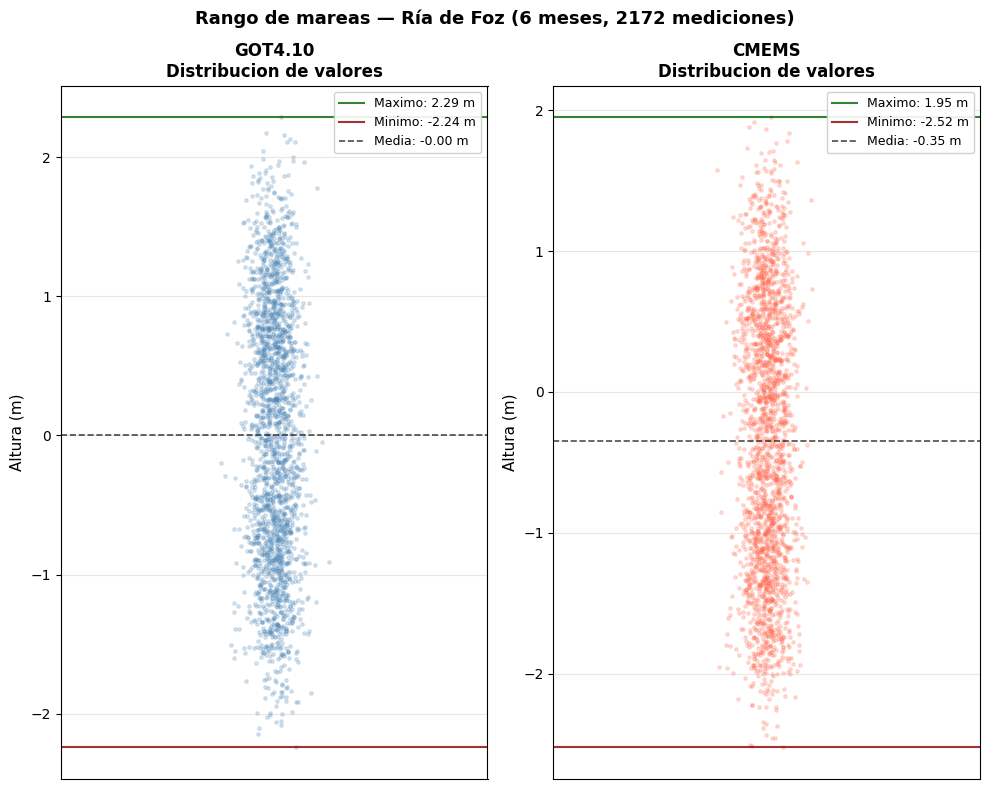

In [15]:
# ────────────────────────────────────────────────────────────────────
# FIGURA 2: Distribución vertical de rangos
# ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 8), sharey=False)

for idx, (col, color) in enumerate(zip(["GOT4.10", "CMEMS"], ["steelblue", "tomato"])):
    ax = axes[idx]
    values = df[col].values
    
    # Scatter vertical con jitter para dispersión
    x_jitter = np.random.normal(0, 0.02, len(values))
    ax.scatter(x_jitter, values, alpha=0.2, s=6, color=color)
    
    # Estadísticos
    v_max = values.max()
    v_min = values.min()
    v_mean = np.mean(values)
    
    # Líneas horizontales
    ax.axhline(v_max, color='darkgreen', linewidth=1.5, linestyle='-', alpha=0.8, label=f'Maximo: {v_max:.2f} m')
    ax.axhline(v_min, color='darkred', linewidth=1.5, linestyle='-', alpha=0.8, label=f'Minimo: {v_min:.2f} m')
    ax.axhline(v_mean, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label=f'Media: {v_mean:.2f} m')
    
    ax.set_xlim(-0.3, 0.3)
    ax.set_xticks([])
    ax.set_ylabel("Altura (m)", fontsize=11)
    ax.set_title(f"{col}\nDistribucion de valores", fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=9, framealpha=0.9)

fig.suptitle("Rango de mareas — Ría de Foz (6 meses, 2172 mediciones)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## Análisis de mareas en horas de paso del satélite

Comparación de las alturas de marea durante los sobrevuelos de Sentinel-2 vs. la distribución completa cada 2h.

Se usan las **36 fechas válidas** del pipeline `foz_sentinel2_scl.ipynb` (`selected_dates_foz`). El flujo es: configuración → horas de sobrevuelo → alturas de marea en esas horas → distribución vertical con los límites analíticos (rango del año completo cada 2 h).


In [16]:
# ────────────────────────────────────────────────────────────────────
# Configuración del AOI de Foz (mismo que foz_sentinel2_scl.ipynb)
# ────────────────────────────────────────────────────────────────────
from intertidal.overpass import get_overpass_times

# Bounding box de la Ría de Foz
bbox_foz = {
    'west': -7.285,
    'south': 43.52,
    'east': -7.205,
    'north': 43.59
}

# Periodo: todo el año 2024
time_extent_2024 = ["2024-01-01", "2024-12-31"]

# ────────────────────────────────────────────────────────────────────
# Fechas VÁLIDAS finales del pipeline foz_sentinel2_scl.ipynb (2024)
# (variable `valid_scene_dates` — 36 fechas que superan el pipeline completo)
#   [ref] 34 fechas con ≤5% píxeles malos globales
#   [✓]    2 fechas recuperadas por el filtro de transición del estuario
# ────────────────────────────────────────────────────────────────────
selected_dates_foz = [
    "2024-01-07", "2024-01-14", "2024-01-19", "2024-01-24",
    "2024-02-03", "2024-02-06", "2024-02-16",
    "2024-03-04", "2024-03-12", "2024-03-14",
    "2024-04-01", "2024-04-21",
    "2024-05-08", "2024-05-11", "2024-05-28",
    "2024-06-02",
    "2024-07-12", "2024-07-22", "2024-07-30",
    "2024-08-04", "2024-08-11", "2024-08-14", "2024-08-16", "2024-08-19", "2024-08-26",
    "2024-09-15", "2024-09-18", "2024-09-23", "2024-09-28",
    "2024-10-13", "2024-10-23",
    "2024-11-02", "2024-11-07", "2024-11-29",
    "2024-12-07", "2024-12-14",
]

print("Configuración cargada:")
print(f"  AOI: Ría de Foz {bbox_foz}")
print(f"  Periodo: {time_extent_2024[0]} → {time_extent_2024[1]}")
print(f"  Fechas válidas del pipeline: {len(selected_dates_foz)}")


Configuración cargada:
  AOI: Ría de Foz {'west': -7.285, 'south': 43.52, 'east': -7.205, 'north': 43.59}
  Periodo: 2024-01-01 → 2024-12-31
  Fechas válidas del pipeline: 36


In [17]:
# ────────────────────────────────────────────────────────────────────
# Obtener horas exactas de paso del satélite Sentinel-2 sobre Foz en 2024
# ────────────────────────────────────────────────────────────────────
print("Consultando catálogo STAC para obtener horas de sobrevuelo...")
t0 = time.time()

overpass_dict = get_overpass_times(bbox_foz, time_extent_2024)

print(f"✓ Obtenidas {len(overpass_dict)} fechas con hora exacta en {time.time()-t0:.1f}s\n")

if not overpass_dict:
    raise RuntimeError(
        "get_overpass_times() devolvió 0 fechas. Revisa la conexión al catálogo STAC, "
        "el bounding box (bbox_foz) o el periodo (time_extent_2024). "
        "Sin escenas no se puede construir overpass_df."
    )

# Convertir a DataFrame para análisis (columnas explícitas para evitar
# KeyError si el diccionario estuviese vacío)
overpass_df = pd.DataFrame(
    [{"date_str": date_str, "datetime": dt} for date_str, dt in overpass_dict.items()],
    columns=["date_str", "datetime"],
).sort_values("datetime").reset_index(drop=True)

# Filtrar solo las fechas seleccionadas
selected_overpass_df = overpass_df[overpass_df["date_str"].isin(selected_dates_foz)].copy()

print(f"Total de sobrevuelos en 2024: {len(overpass_df)}")
print(f"Sobrevuelos en fechas seleccionadas: {len(selected_overpass_df)}")
print(f"\nPrimeros 5 sobrevuelos:")
for _, row in overpass_df.head().iterrows():
    print(f"  {row['datetime'].strftime('%Y-%m-%d %H:%M:%S')}")


Consultando catálogo STAC para obtener horas de sobrevuelo...
✓ Obtenidas 144 fechas con hora exacta en 7.9s

Total de sobrevuelos en 2024: 144
Sobrevuelos en fechas seleccionadas: 36

Primeros 5 sobrevuelos:
  2024-01-02 11:35:01
  2024-01-04 11:23:59
  2024-01-07 11:33:49
  2024-01-09 11:24:41
  2024-01-12 11:34:31


In [18]:
# ────────────────────────────────────────────────────────────────────
# Calcular alturas de marea en horas exactas de sobrevuelo (TODAS las fechas 2024)
# ────────────────────────────────────────────────────────────────────
print("Calculando mareas GOT4.10 en horas de sobrevuelo (todas las fechas)...")
t0 = time.time()
got_overpass_all = model_got.get_tide_heights_batch(LAT, LON, overpass_df["datetime"].tolist())
print(f"✓ GOT4.10: {len(got_overpass_all)} valores en {time.time()-t0:.1f}s")

print("\nCalculando mareas CMEMS en horas de sobrevuelo (todas las fechas)...")
t0 = time.time()
cmems_overpass_all = model_cmems.get_tide_heights_batch(LAT, LON, overpass_df["datetime"].tolist())
print(f"✓ CMEMS: {len(cmems_overpass_all)} valores en {time.time()-t0:.1f}s")

# Añadir al DataFrame
overpass_df["GOT4.10"] = got_overpass_all
overpass_df["CMEMS"] = cmems_overpass_all


Calculando mareas GOT4.10 en horas de sobrevuelo (todas las fechas)...
✓ GOT4.10: 144 valores en 7.6s

Calculando mareas CMEMS en horas de sobrevuelo (todas las fechas)...


INFO - 2026-07-02T11:36:51Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-02T11:36:51Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


✓ CMEMS: 144 valores en 8.9s


In [19]:
# ────────────────────────────────────────────────────────────────────
# Calcular alturas de marea en horas exactas de sobrevuelo (SOLO fechas seleccionadas)
# ────────────────────────────────────────────────────────────────────
print("Calculando mareas GOT4.10 en horas de sobrevuelo (fechas seleccionadas)...")
t0 = time.time()
got_overpass_selected = model_got.get_tide_heights_batch(LAT, LON, selected_overpass_df["datetime"].tolist())
print(f"✓ GOT4.10: {len(got_overpass_selected)} valores en {time.time()-t0:.1f}s")

print("\nCalculando mareas CMEMS en horas de sobrevuelo (fechas seleccionadas)...")
t0 = time.time()
cmems_overpass_selected = model_cmems.get_tide_heights_batch(LAT, LON, selected_overpass_df["datetime"].tolist())
print(f"✓ CMEMS: {len(cmems_overpass_selected)} valores en {time.time()-t0:.1f}s")

# Añadir al DataFrame
selected_overpass_df["GOT4.10"] = got_overpass_selected
selected_overpass_df["CMEMS"] = cmems_overpass_selected

print(f"\nEstadísticas mareas en fechas seleccionadas:")
print(f"  GOT4.10 → min: {min(got_overpass_selected):.2f} m, max: {max(got_overpass_selected):.2f} m")
print(f"  CMEMS   → min: {min(cmems_overpass_selected):.2f} m, max: {max(cmems_overpass_selected):.2f} m")


Calculando mareas GOT4.10 en horas de sobrevuelo (fechas seleccionadas)...
✓ GOT4.10: 36 valores en 7.3s

Calculando mareas CMEMS en horas de sobrevuelo (fechas seleccionadas)...


INFO - 2026-07-02T11:37:07Z - Selected dataset version: "202511"
INFO:copernicusmarine:Selected dataset version: "202511"
INFO - 2026-07-02T11:37:07Z - Selected dataset part: "default"
INFO:copernicusmarine:Selected dataset part: "default"


✓ CMEMS: 36 valores en 10.1s

Estadísticas mareas en fechas seleccionadas:
  GOT4.10 → min: -2.06 m, max: 1.13 m
  CMEMS   → min: -2.10 m, max: 0.98 m


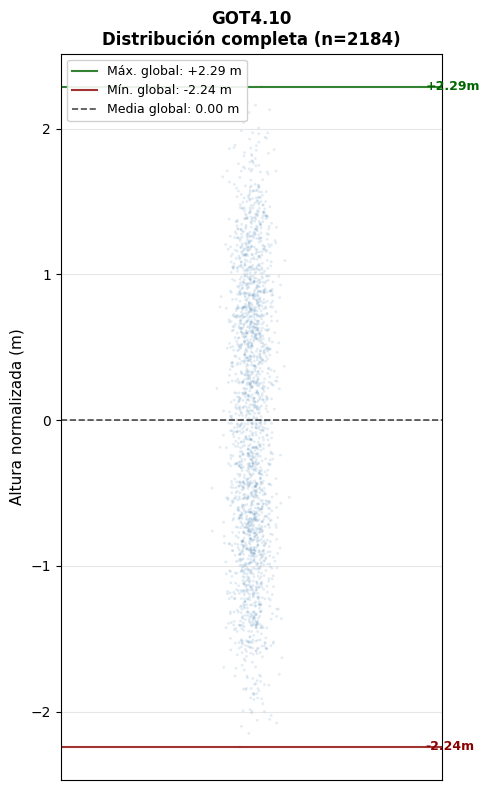

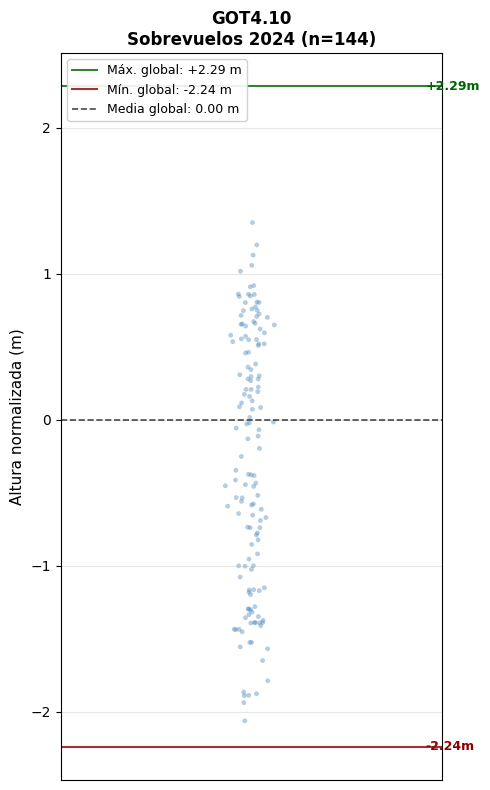

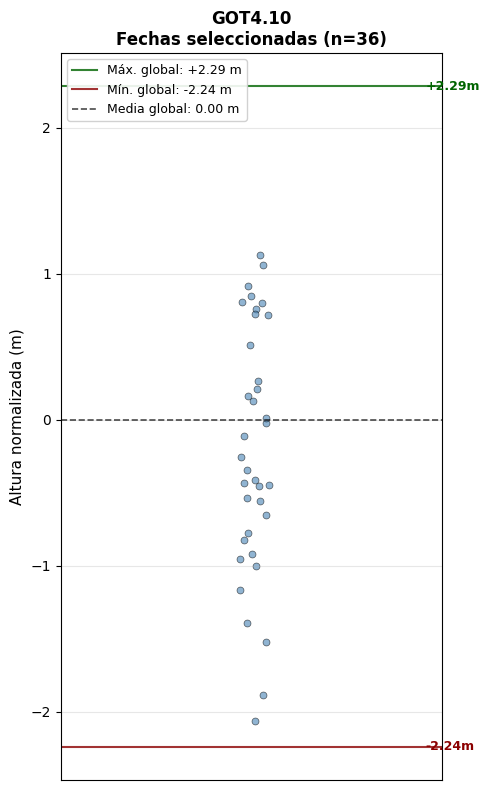

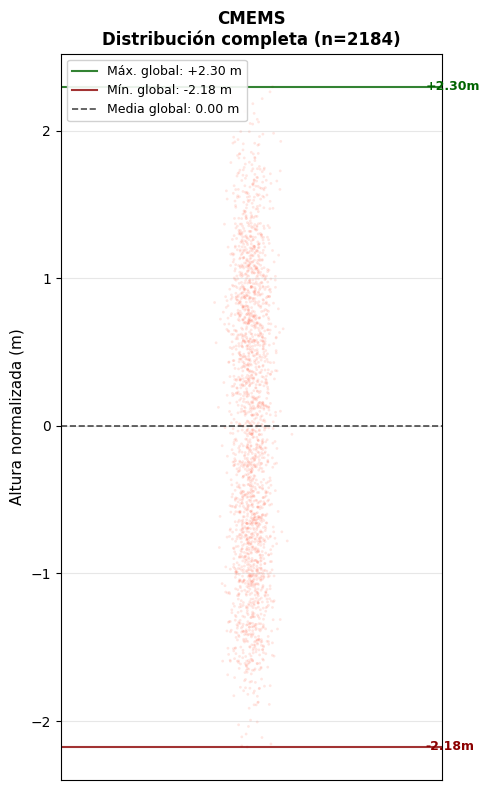

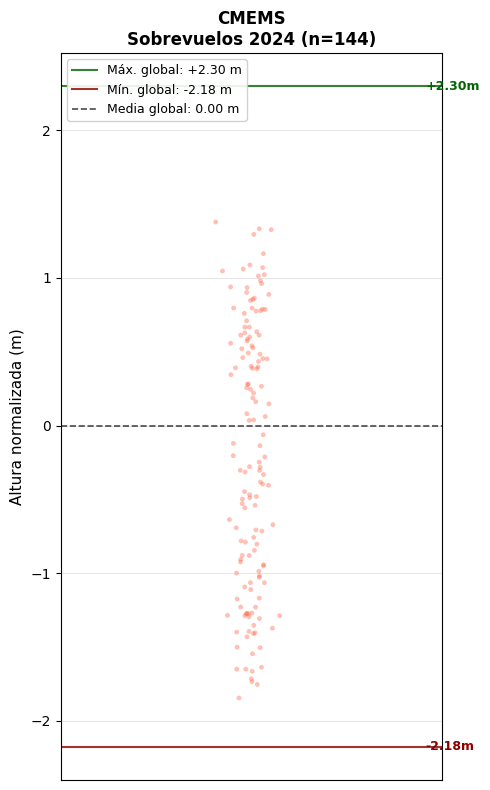

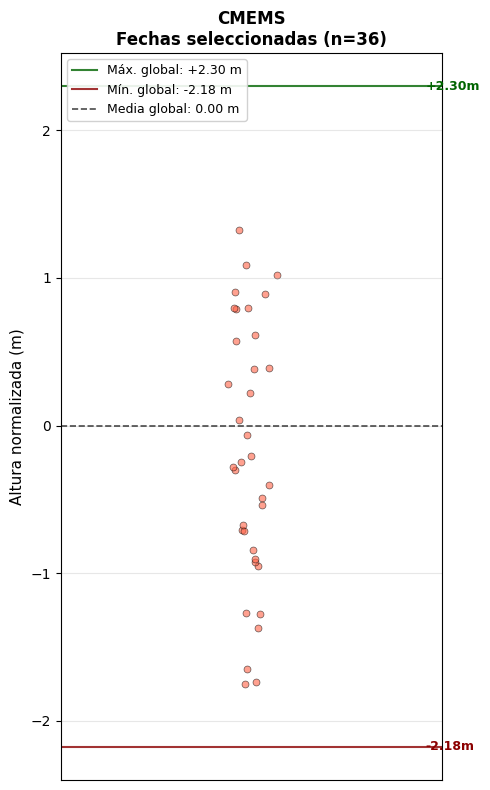

In [20]:
# ────────────────────────────────────────────────────────────────────
# FIGURA 3: Distribución de mareas en sobrevuelos vs. distribución completa
# Cada distribución en su propia figura.
#  · Valores NORMALIZADOS restando la media de la distribución completa
#    de cada modelo (todas las figuras comparten el mismo marco).
#  · Las líneas de límite superior/inferior son SIEMPRE las de la
#    distribución completa (primer plot), no las del subconjunto.
# ────────────────────────────────────────────────────────────────────

def plot_distribucion(values_norm, color, title, ylim, ref_min, ref_max, s=6, alpha=0.2):
    """Dibuja una distribución vertical normalizada en su propia figura.

    Los límites (ref_min/ref_max) provienen SIEMPRE de la distribución
    completa, no de `values_norm`.
    """
    fig, ax = plt.subplots(figsize=(5, 8))
    x_jitter = np.random.normal(0, 0.02, len(values_norm))
    ax.scatter(x_jitter, values_norm, alpha=alpha, s=s, color=color,
               edgecolor='black' if s >= 25 else 'none', linewidth=0.5)

    # Límites de referencia = distribución completa (iguales en todas las figuras)
    ax.axhline(ref_max, color='darkgreen', linewidth=1.5, linestyle='-', alpha=0.8, label=f'Máx. global: {ref_max:+.2f} m')
    ax.axhline(ref_min, color='darkred', linewidth=1.5, linestyle='-', alpha=0.8, label=f'Mín. global: {ref_min:+.2f} m')
    ax.axhline(0, color='black', linewidth=1.2, linestyle='--', alpha=0.7, label='Media global: 0.00 m')

    ax.text(0.32, ref_max, f'{ref_max:+.2f}m', fontsize=9, va='center', color='darkgreen', fontweight='bold')
    ax.text(0.32, ref_min, f'{ref_min:+.2f}m', fontsize=9, va='center', color='darkred', fontweight='bold')

    ax.set_xlim(-0.35, 0.35)
    ax.set_ylim(ylim)               # ← MISMOS límites en todas las figuras
    ax.set_xticks([])
    ax.set_ylabel("Altura normalizada (m)", fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(alpha=0.3, axis='y')
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    plt.tight_layout()
    plt.show()


for col, color in zip(["GOT4.10", "CMEMS"], ["steelblue", "tomato"]):
    # Referencia = distribución completa del modelo
    values_full = df[col].values
    full_mean = np.mean(values_full)

    # Normalizar TODO restando la media de la distribución completa
    full_norm = values_full - full_mean

    # Límites globales (de la distribución completa normalizada)
    ref_min, ref_max = full_norm.min(), full_norm.max()
    margin = 0.05 * (ref_max - ref_min)
    ylim = (ref_min - margin, ref_max + margin)

    # ── Figura A: distribución completa (cada 2h, 6 meses) ──────────────
    plot_distribucion(
        full_norm, color,
        title=f"{col}\nDistribución completa (n={len(full_norm)})",
        ylim=ylim, ref_min=ref_min, ref_max=ref_max, s=4, alpha=0.15,
    )

    # ── Figura B: sobrevuelos todas las fechas 2024 ─────────────────────
    overpass_norm = overpass_df[col].values - full_mean
    plot_distribucion(
        overpass_norm, color,
        title=f"{col}\nSobrevuelos 2024 (n={len(overpass_norm)})",
        ylim=ylim, ref_min=ref_min, ref_max=ref_max, s=12, alpha=0.4,
    )

    # ── Figura C: sobrevuelos solo fechas seleccionadas ─────────────────
    selected_norm = selected_overpass_df[col].values - full_mean
    plot_distribucion(
        selected_norm, color,
        title=f"{col}\nFechas seleccionadas (n={len(selected_norm)})",
        ylim=ylim, ref_min=ref_min, ref_max=ref_max, s=25, alpha=0.6,
    )
